In [1]:
 # ============================================================
# NB3 · Cell 1 — Setup, dataset path, load NB2 checkpoint
# ============================================================
import os, sys, json, random, time
from collections import Counter
from pathlib import Path

import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms, models
from PIL import Image
import matplotlib.pyplot as plt

# Reproducibility
SEED = 42
random.seed(SEED); np.random.seed(SEED)
torch.manual_seed(SEED); torch.cuda.manual_seed_all(SEED)

# GPU check
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device : {device}")
if device.type == "cuda":
    print(f"GPU    : {torch.cuda.get_device_name(0)}")
print()

# --- Find the PlantVillage maize folder (same logic as NB1/NB2) ---
candidates = [
    "/kaggle/input/plantvillage-dataset/color",
    "/kaggle/input/plantvillage-dataset/plantvillage dataset/color",
    "/kaggle/input/datasets/abdallahalidev/plantvillage-dataset/color",
]
COLOR_DIR = next((c for c in candidates
                  if os.path.isdir(c) and any("Corn" in d for d in os.listdir(c))), None)
assert COLOR_DIR, f"PlantVillage path not found. /kaggle/input contents: {os.listdir('/kaggle/input')}"
maize_dirs = sorted([d for d in os.listdir(COLOR_DIR) if "Corn" in d])
assert len(maize_dirs) == 4
print(f"Dataset path : {COLOR_DIR}")
print(f"Maize classes: {len(maize_dirs)}")

# --- Find the NB2 checkpoint ---
print("\nSearching for swin_t_best.pt under /kaggle/input/...")
ckpt_path = None
for root, dirs, files in os.walk("/kaggle/input"):
    if "swin_t_best.pt" in files:
        ckpt_path = os.path.join(root, "swin_t_best.pt")
        break
assert ckpt_path, "Couldn't find swin_t_best.pt. Did you attach your NB2 notebook output?"
print(f"NB2 checkpoint : {ckpt_path}")
size_mb = os.path.getsize(ckpt_path) / 1e6
print(f"Checkpoint size: {size_mb:.0f} MB  (expect ~107 MB)")

# --- Build the same Swin-T architecture, load NB2's weights ---
print("\nRebuilding Swin-T architecture and loading NB2 weights...")
model = models.swin_t(weights=None)   # no need for ImageNet weights — we'll overwrite
model.head = nn.Sequential(
    nn.Dropout(0.3),
    nn.Linear(model.head.in_features, 4)
)
state = torch.load(ckpt_path, map_location=device)
model.load_state_dict(state)
model = model.to(device).eval()
print("✅ Swin-T loaded with NB2's fine-tuned weights")

# --- Sanity check: forward pass produces 4-class logits ---
with torch.no_grad():
    x_dummy = torch.randn(2, 3, 224, 224, device=device)
    out = model(x_dummy)
print(f"Forward pass : {tuple(x_dummy.shape)} → {tuple(out.shape)}  (expect (2, 4))")

print("\nCell 1 complete ✅")

Device : cuda
GPU    : Tesla T4

Dataset path : /kaggle/input/datasets/abdallahalidev/plantvillage-dataset/color
Maize classes: 4

Searching for swin_t_best.pt under /kaggle/input/...


AssertionError: Couldn't find swin_t_best.pt. Did you attach your NB2 notebook output?

In [2]:
# ============================================================
# NB3 · Cell 1 — Setup, dataset path, load NB2 checkpoint
# ============================================================
import os, sys, json, random, time
from collections import Counter
from pathlib import Path

import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms, models
from PIL import Image
import matplotlib.pyplot as plt

# Reproducibility
SEED = 42
random.seed(SEED); np.random.seed(SEED)
torch.manual_seed(SEED); torch.cuda.manual_seed_all(SEED)

# GPU check
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device : {device}")
if device.type == "cuda":
    print(f"GPU    : {torch.cuda.get_device_name(0)}")
print()

# --- Find the PlantVillage maize folder ---
candidates = [
    "/kaggle/input/plantvillage-dataset/color",
    "/kaggle/input/plantvillage-dataset/plantvillage dataset/color",
    "/kaggle/input/datasets/abdallahalidev/plantvillage-dataset/color",
]
COLOR_DIR = next((c for c in candidates
                  if os.path.isdir(c) and any("Corn" in d for d in os.listdir(c))), None)
assert COLOR_DIR, f"PlantVillage path not found. /kaggle/input contents: {os.listdir('/kaggle/input')}"
maize_dirs = sorted([d for d in os.listdir(COLOR_DIR) if "Corn" in d])
assert len(maize_dirs) == 4
print(f"Dataset path : {COLOR_DIR}")
print(f"Maize classes: {len(maize_dirs)}")

# --- Find the NB2 checkpoint anywhere under /kaggle/input ---
print("\nSearching for swin_t_best.pt under /kaggle/input/...")
ckpt_path = None
for root, dirs, files in os.walk("/kaggle/input"):
    if "swin_t_best.pt" in files:
        ckpt_path = os.path.join(root, "swin_t_best.pt")
        break
assert ckpt_path, "Couldn't find swin_t_best.pt. Did you attach the checkpoint dataset?"
print(f"NB2 checkpoint : {ckpt_path}")
size_mb = os.path.getsize(ckpt_path) / 1e6
print(f"Checkpoint size: {size_mb:.0f} MB  (expect ~107 MB)")

# --- Build the same Swin-T architecture, load NB2's weights ---
print("\nRebuilding Swin-T architecture and loading NB2 weights...")
model = models.swin_t(weights=None)
model.head = nn.Sequential(
    nn.Dropout(0.3),
    nn.Linear(model.head.in_features, 4)
)
state = torch.load(ckpt_path, map_location=device)
model.load_state_dict(state)
model = model.to(device).eval()
print("✅ Swin-T loaded with NB2's fine-tuned weights")

# --- Sanity check ---
with torch.no_grad():
    x_dummy = torch.randn(2, 3, 224, 224, device=device)
    out = model(x_dummy)
print(f"Forward pass : {tuple(x_dummy.shape)} → {tuple(out.shape)}  (expect (2, 4))")

print("\nCell 1 complete ✅")

Device : cuda
GPU    : Tesla T4

Dataset path : /kaggle/input/datasets/abdallahalidev/plantvillage-dataset/color
Maize classes: 4

Searching for swin_t_best.pt under /kaggle/input/...
NB2 checkpoint : /kaggle/input/datasets/aproton/output-from-nb2/swin_t_best.pt
Checkpoint size: 110 MB  (expect ~107 MB)

Rebuilding Swin-T architecture and loading NB2 weights...
✅ Swin-T loaded with NB2's fine-tuned weights
Forward pass : (2, 3, 224, 224) → (2, 4)  (expect (2, 4))

Cell 1 complete ✅


In [3]:
# ============================================================
# NB3 · Cell 2 — Reproduce splits + extract Swin-T embeddings
# ============================================================
from sklearn.model_selection import train_test_split

# --- Friendly class names (same as NB1/NB2) ---
def friendly(name):
    n = name.lower()
    if "cercospora" in n or "gray" in n: return "Gray Leaf Spot"
    if "common_rust" in n or "rust" in n: return "Common Rust"
    if "northern" in n or "blight" in n:  return "Northern Leaf Blight"
    if "healthy" in n:                     return "Healthy"
    return name

raw_names      = sorted(maize_dirs)
DISPLAY_NAMES  = [friendly(n) for n in raw_names]
CLASS_TO_IDX   = {raw_names[i]: i for i in range(4)}

# --- Build all (path, label) pairs ---
all_paths, all_labels = [], []
for folder_name in raw_names:
    label = CLASS_TO_IDX[folder_name]
    folder_path = os.path.join(COLOR_DIR, folder_name)
    for img in os.listdir(folder_path):
        if img.lower().endswith((".jpg", ".jpeg", ".png")):
            all_paths.append(os.path.join(folder_path, img))
            all_labels.append(label)

# --- Reproduce the EXACT same 70/15/15 split as NB1/NB2 (same SEED) ---
train_paths, tmp_paths, train_labels, tmp_labels = train_test_split(
    all_paths, all_labels, test_size=0.30, stratify=all_labels, random_state=SEED)
val_paths, test_paths, val_labels, test_labels = train_test_split(
    tmp_paths, tmp_labels, test_size=0.50, stratify=tmp_labels, random_state=SEED)
print(f"Total images   : {len(all_paths)}")
print(f"Train/Val/Test : {len(train_paths)} / {len(val_paths)} / {len(test_paths)}")

# --- Eval transform (deterministic, no augmentation) ---
IMG_SIZE = 224
IMAGENET_MEAN = [0.485, 0.456, 0.406]
IMAGENET_STD  = [0.229, 0.224, 0.225]
eval_tfm = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(IMAGENET_MEAN, IMAGENET_STD),
])

class MaizeDataset(Dataset):
    def __init__(self, paths, labels, tfm):
        self.paths, self.labels, self.tfm = paths, labels, tfm
    def __len__(self):
        return len(self.paths)
    def __getitem__(self, i):
        img = Image.open(self.paths[i]).convert("RGB")
        return self.tfm(img), self.labels[i]

test_ds     = MaizeDataset(test_paths, test_labels, eval_tfm)
test_loader = DataLoader(test_ds, batch_size=32, shuffle=False, num_workers=0, pin_memory=True)

# --- Extract Swin-T embeddings (768-d, the layer right before the head) ---
@torch.no_grad()
def extract_embeddings(model, loader, device):
    """Run images through Swin-T everything-except-head, return (N, 768) embeddings + labels."""
    model.eval()
    feats_all, labels_all = [], []
    for x, y in loader:
        x = x.to(device, non_blocking=True)
        # Forward through Swin-T's pre-head pipeline
        f = model.features(x)
        f = model.norm(f)
        f = model.permute(f)
        f = model.avgpool(f)
        f = model.flatten(f)              # (B, 768)
        feats_all.append(f.cpu())
        labels_all.append(y)
    return torch.cat(feats_all, dim=0), torch.cat(labels_all, dim=0)

print("\nExtracting Swin-T embeddings for the test split...")
t0 = time.time()
test_embeddings, test_lbls = extract_embeddings(model, test_loader, device)
elapsed = time.time() - t0
print(f"Embeddings shape : {tuple(test_embeddings.shape)}  (expect ({len(test_paths)}, 768))")
print(f"Labels shape     : {tuple(test_lbls.shape)}")
print(f"Extraction time  : {elapsed:.1f} sec")

# --- Group embeddings by class for fast episodic sampling later ---
embeddings_by_class = {}
print("\nEmbeddings per class:")
for c in range(4):
    mask = (test_lbls == c)
    embeddings_by_class[c] = test_embeddings[mask]
    print(f"  Class {c} ({DISPLAY_NAMES[c]:<22}): {embeddings_by_class[c].shape[0]} embeddings of dim {embeddings_by_class[c].shape[1]}")

# Quick sanity check: embeddings for the same class should cluster
# (mean intra-class distance < mean inter-class distance)
print("\nQuick clustering sanity check (lower intra > inter is bad):")
intra_dists = []
inter_dists = []
for c in range(4):
    cls = embeddings_by_class[c]
    # Mean distance within class
    if len(cls) > 1:
        # Sample 50 pairs
        idx1 = torch.randint(0, len(cls), (50,))
        idx2 = torch.randint(0, len(cls), (50,))
        d = (cls[idx1] - cls[idx2]).pow(2).sum(dim=1).sqrt()
        intra_dists.append(d.mean().item())
    # Mean distance to other classes
    other = torch.cat([embeddings_by_class[k] for k in range(4) if k != c])
    idx1 = torch.randint(0, len(cls), (50,))
    idx2 = torch.randint(0, len(other), (50,))
    d = (cls[idx1] - other[idx2]).pow(2).sum(dim=1).sqrt()
    inter_dists.append(d.mean().item())

print(f"  Mean intra-class L2 distance : {np.mean(intra_dists):.2f}")
print(f"  Mean inter-class L2 distance : {np.mean(inter_dists):.2f}")
print(f"  Inter / Intra ratio          : {np.mean(inter_dists)/np.mean(intra_dists):.2f}  (expect > 1.5 for separable classes)")

print("\nCell 2 complete ✅")

Total images   : 3852
Train/Val/Test : 2696 / 578 / 578

Extracting Swin-T embeddings for the test split...
Embeddings shape : (578, 768)  (expect (578, 768))
Labels shape     : (578,)
Extraction time  : 6.5 sec

Embeddings per class:
  Class 0 (Gray Leaf Spot        ): 77 embeddings of dim 768
  Class 1 (Common Rust           ): 179 embeddings of dim 768
  Class 2 (Northern Leaf Blight  ): 148 embeddings of dim 768
  Class 3 (Healthy               ): 174 embeddings of dim 768

Quick clustering sanity check (lower intra > inter is bad):
  Mean intra-class L2 distance : 21.89
  Mean inter-class L2 distance : 35.48
  Inter / Intra ratio          : 1.62  (expect > 1.5 for separable classes)

Cell 2 complete ✅


In [4]:
# ============================================================
# NB3 · Cell 3 — Few-shot episodic evaluation (4-way K-shot)
# ============================================================

# --- Sample a single episode ---
def sample_episode(embeddings_by_class, n_way, k_shot, n_query, rng):
    """Pick n_way classes, draw k_shot support + n_query query per class.
    Returns: (support_embs, support_labs, query_embs, query_labs)."""
    classes = sorted(embeddings_by_class.keys())
    selected = rng.choice(classes, size=n_way, replace=False)

    s_embs, s_labs, q_embs, q_labs = [], [], [], []
    for new_lab, orig_class in enumerate(selected):
        cls_embs = embeddings_by_class[int(orig_class)]
        n = len(cls_embs)
        idx = rng.permutation(n)[:k_shot + n_query]
        s_embs.append(cls_embs[idx[:k_shot]])
        q_embs.append(cls_embs[idx[k_shot:k_shot + n_query]])
        s_labs.extend([new_lab] * k_shot)
        q_labs.extend([new_lab] * n_query)
    return (torch.cat(s_embs), torch.tensor(s_labs),
            torch.cat(q_embs), torch.tensor(q_labs))

# --- Prototypical classifier ---
def prototypical_classify(s_embs, s_labs, q_embs, n_way, distance="euclidean", normalize=False):
    """Compute one prototype per class (mean of support), classify queries by distance."""
    if normalize:
        s_embs = F.normalize(s_embs, dim=1)
        q_embs = F.normalize(q_embs, dim=1)

    # Prototype per class (n_way, 768)
    prototypes = torch.stack([s_embs[s_labs == c].mean(dim=0) for c in range(n_way)])

    if distance == "euclidean":
        dists = torch.cdist(q_embs, prototypes, p=2)        # (n_query, n_way)
    elif distance == "cosine":
        dists = 1.0 - q_embs @ prototypes.T                  # (n_query, n_way)
    else:
        raise ValueError(f"Unknown distance: {distance}")

    return dists.argmin(dim=1)

# --- Run many episodes, return mean ± 95% CI ---
def run_episodes(embeddings_by_class, n_way, k_shot, n_query, n_episodes,
                 distance="euclidean", normalize=False, seed=42):
    rng = np.random.RandomState(seed)
    accs = np.empty(n_episodes, dtype=np.float32)
    for i in range(n_episodes):
        s_embs, s_labs, q_embs, q_labs = sample_episode(
            embeddings_by_class, n_way, k_shot, n_query, rng)
        preds = prototypical_classify(s_embs, s_labs, q_embs, n_way, distance, normalize)
        accs[i] = (preds == q_labs).float().mean().item()
    mean_acc = accs.mean()
    ci95     = 1.96 * accs.std() / np.sqrt(n_episodes)
    return float(mean_acc), float(ci95), accs

# --- Run all 4 settings ---
N_WAY      = 4
N_QUERY    = 15
N_EPISODES = 1000

print(f"Protocol: {N_WAY}-way K-shot · {N_QUERY} queries per class · {N_EPISODES} episodes per setting\n")

settings = [
    ("Euclidean (raw)",       "euclidean", False),
    ("Cosine (L2-normalized)","cosine",    True),
]
results = {}

for k_shot in [1, 5]:
    print(f"--- {N_WAY}-way {k_shot}-shot ---")
    for label, dist, norm in settings:
        t0 = time.time()
        mean_acc, ci95, accs = run_episodes(
            embeddings_by_class, N_WAY, k_shot, N_QUERY, N_EPISODES,
            distance=dist, normalize=norm, seed=SEED + k_shot
        )
        elapsed = time.time() - t0
        print(f"  {label:<26}: {mean_acc*100:6.2f}% ± {ci95*100:.2f}%   [{elapsed:.1f}s, {N_EPISODES} episodes]")
        results[f"{N_WAY}way_{k_shot}shot_{dist}{'_norm' if norm else ''}"] = {
            "n_way": N_WAY, "k_shot": k_shot, "n_query": N_QUERY, "n_episodes": N_EPISODES,
            "distance": dist, "normalize": norm,
            "mean_accuracy": mean_acc, "ci95": ci95,
            "all_accuracies": accs.tolist()
        }
    print()

# --- Headline summary ---
print("=" * 70)
print("PAPER TABLE 2 — Few-shot prototype classification on PlantVillage maize")
print("=" * 70)
print(f"{'Setting':<35}{'Accuracy':>15}{'95% CI':>15}")
print("-" * 70)
for k_shot in [1, 5]:
    for label, dist, norm in settings:
        key = f"{N_WAY}way_{k_shot}shot_{dist}{'_norm' if norm else ''}"
        r = results[key]
        setting_str = f"{N_WAY}-way {k_shot}-shot, {label}"
        print(f"{setting_str:<35}{r['mean_accuracy']*100:>13.2f}%{'± ' + f'{r['ci95']*100:.2f}%':>15}")
print("=" * 70)

# --- Project plan target check ---
target_1shot = 0.70
best_1shot = max(r["mean_accuracy"] for k, r in results.items() if "1shot" in k)
print(f"\nProject plan target: 4-way 1-shot accuracy > {target_1shot*100:.0f}%")
print(f"Best 1-shot achieved: {best_1shot*100:.2f}%  →  {'✅ exceeded' if best_1shot > target_1shot else '⚠️  below target'}")

print("\nCell 3 complete ✅")

Protocol: 4-way K-shot · 15 queries per class · 1000 episodes per setting

--- 4-way 1-shot ---
  Euclidean (raw)           :  87.91% ± 0.40%   [0.9s, 1000 episodes]
  Cosine (L2-normalized)    :  88.94% ± 0.37%   [0.9s, 1000 episodes]

--- 4-way 5-shot ---
  Euclidean (raw)           :  95.17% ± 0.19%   [0.9s, 1000 episodes]
  Cosine (L2-normalized)    :  94.64% ± 0.20%   [0.9s, 1000 episodes]

PAPER TABLE 2 — Few-shot prototype classification on PlantVillage maize
Setting                                   Accuracy         95% CI
----------------------------------------------------------------------
4-way 1-shot, Euclidean (raw)              87.91%        ± 0.40%
4-way 1-shot, Cosine (L2-normalized)        88.94%        ± 0.37%
4-way 5-shot, Euclidean (raw)              95.17%        ± 0.19%
4-way 5-shot, Cosine (L2-normalized)        94.64%        ± 0.20%

Project plan target: 4-way 1-shot accuracy > 70%
Best 1-shot achieved: 88.94%  →  ✅ exceeded

Cell 3 complete ✅


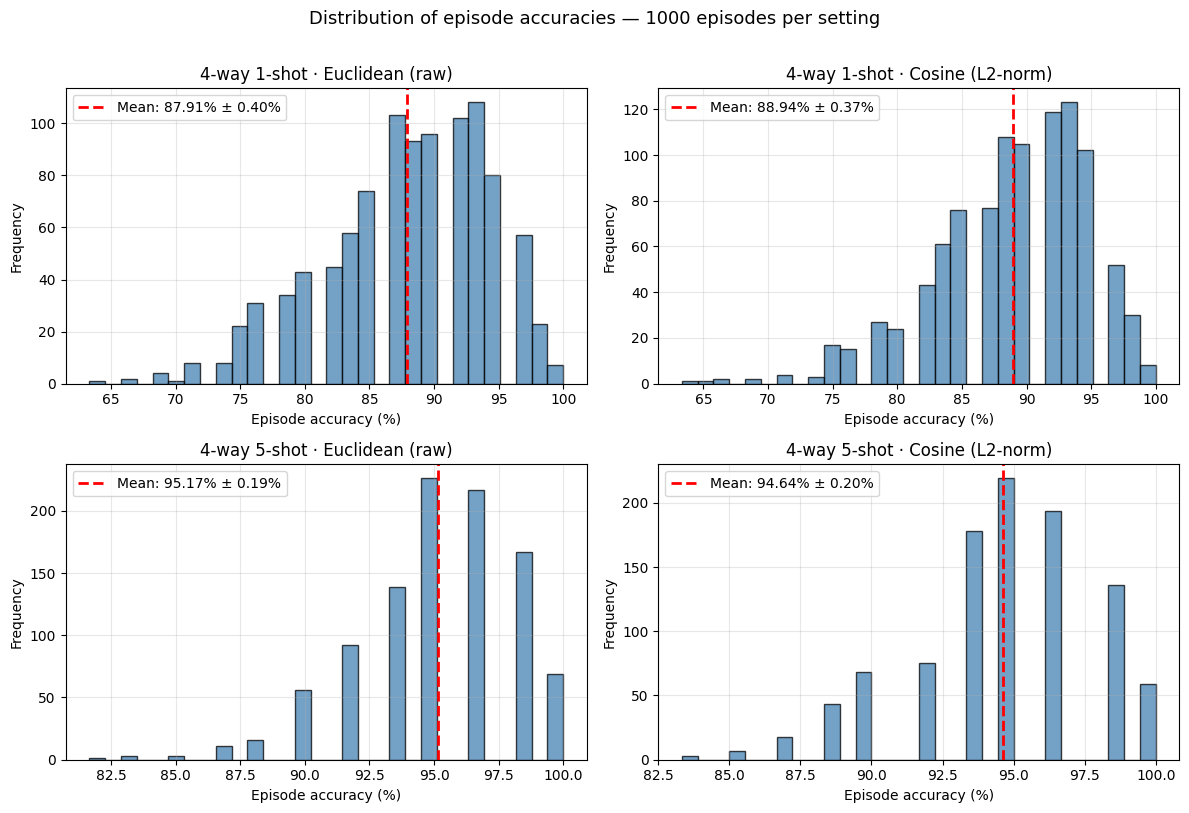

Saved: /kaggle/working/nb3_episode_distributions.png



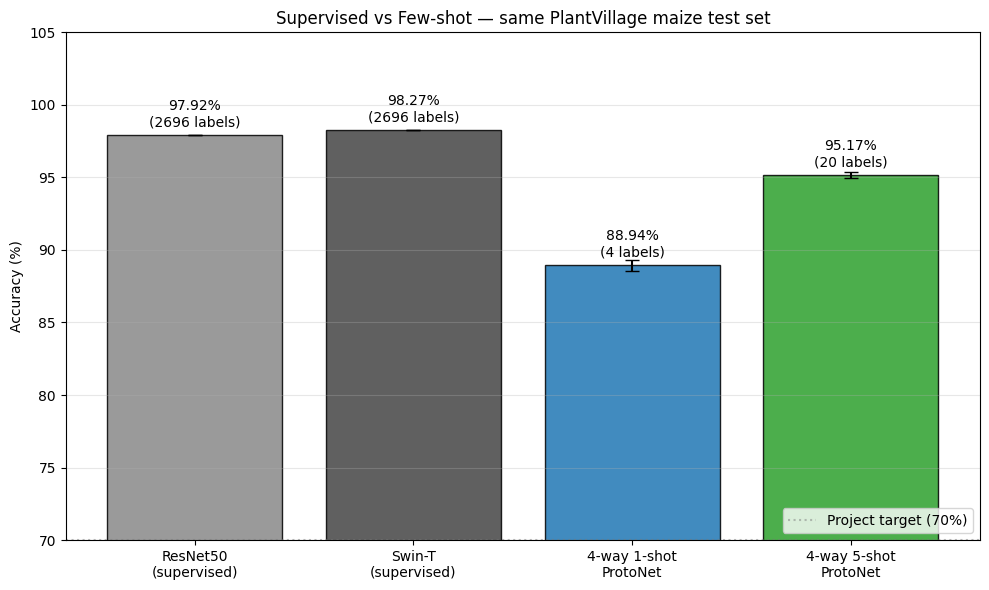

Saved: /kaggle/working/nb3_supervised_vs_fewshot.png

Results saved to: /kaggle/working/nb3_protonet_results.json

NB3 — Final summary (PAPER TABLE 2 candidate)
Method                                             Accuracy         Labels
------------------------------------------------------------------------------
ResNet50 (supervised, NB1)                           97.92%           2696
Swin-T (supervised, NB2)                             98.27%           2696
4-way 1-shot ProtoNet (best: cosine+norm)            88.94%              4
4-way 5-shot ProtoNet (best: euclidean)              95.17%             20

Cell 4 complete ✅

NB3 is officially DONE. 🎉


In [5]:
# ============================================================
# NB3 · Cell 4 — Visualizations + save results JSON
# ============================================================

# Supervised baselines from NB1/NB2
SUPERVISED_BASELINES = {
    "ResNet50 (full)": {"accuracy": 0.9792, "macro_f1": 0.9698},
    "Swin-T (full)":   {"accuracy": 0.9827, "macro_f1": 0.9752},
}

# --- Figure 1: Episode accuracy distributions (2x2 grid) ---
fig, axes = plt.subplots(2, 2, figsize=(12, 8))
plot_settings = [
    (1, "euclidean", False, "1-shot · Euclidean (raw)",       axes[0, 0]),
    (1, "cosine",    True,  "1-shot · Cosine (L2-norm)",      axes[0, 1]),
    (5, "euclidean", False, "5-shot · Euclidean (raw)",       axes[1, 0]),
    (5, "cosine",    True,  "5-shot · Cosine (L2-norm)",      axes[1, 1]),
]
for k_shot, dist, norm, title, ax in plot_settings:
    key  = f"{N_WAY}way_{k_shot}shot_{dist}{'_norm' if norm else ''}"
    accs = np.array(results[key]["all_accuracies"]) * 100
    mean = accs.mean()
    ci   = results[key]["ci95"] * 100

    ax.hist(accs, bins=30, edgecolor="black", alpha=0.75, color="steelblue")
    ax.axvline(mean, color="red", linestyle="--", linewidth=2, label=f"Mean: {mean:.2f}% ± {ci:.2f}%")
    ax.set_xlabel("Episode accuracy (%)")
    ax.set_ylabel("Frequency")
    ax.set_title(f"{N_WAY}-way {title}")
    ax.legend()
    ax.grid(alpha=0.3)

plt.suptitle(f"Distribution of episode accuracies — {N_EPISODES} episodes per setting", fontsize=13, y=1.01)
plt.tight_layout()
HIST_PATH = "/kaggle/working/nb3_episode_distributions.png"
plt.savefig(HIST_PATH, dpi=150, bbox_inches="tight")
plt.show()
print(f"Saved: {HIST_PATH}\n")

# --- Figure 2: Supervised vs Few-shot comparison ---
fig, ax = plt.subplots(figsize=(10, 6))

methods, accuracies, errors, colors, n_labels_used = [], [], [], [], []

# Supervised
methods.append("ResNet50\n(supervised)")
accuracies.append(0.9792); errors.append(0); colors.append("#888888")
n_labels_used.append(len(train_paths))

methods.append("Swin-T\n(supervised)")
accuracies.append(0.9827); errors.append(0); colors.append("#444444")
n_labels_used.append(len(train_paths))

# Few-shot — pick best variant per K
for k_shot, color in [(1, "#1f77b4"), (5, "#2ca02c")]:
    best_key = max([k for k in results if f"_{k_shot}shot_" in k],
                   key=lambda k: results[k]["mean_accuracy"])
    r = results[best_key]
    methods.append(f"{N_WAY}-way {k_shot}-shot\nProtoNet")
    accuracies.append(r["mean_accuracy"])
    errors.append(r["ci95"])
    colors.append(color)
    n_labels_used.append(k_shot * N_WAY)

x = np.arange(len(methods))
bars = ax.bar(x, np.array(accuracies)*100, yerr=np.array(errors)*100,
              capsize=5, color=colors, edgecolor="black", alpha=0.85)

# Annotate each bar with accuracy + label count
for i, (bar, acc, n) in enumerate(zip(bars, accuracies, n_labels_used)):
    label = f"{acc*100:.2f}%\n({n} labels)"
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.4,
            label, ha="center", va="bottom", fontsize=10)

ax.set_xticks(x)
ax.set_xticklabels(methods)
ax.set_ylabel("Accuracy (%)")
ax.set_ylim(70, 105)
ax.set_title("Supervised vs Few-shot — same PlantVillage maize test set")
ax.axhline(y=70, color="gray", linestyle=":", alpha=0.5, label="Project target (70%)")
ax.grid(axis="y", alpha=0.3)
ax.legend(loc="lower right")

plt.tight_layout()
COMP_PATH = "/kaggle/working/nb3_supervised_vs_fewshot.png"
plt.savefig(COMP_PATH, dpi=150, bbox_inches="tight")
plt.show()
print(f"Saved: {COMP_PATH}\n")

# --- Save results JSON ---
nb3_results = {
    "notebook":          "NB3_PrototypicalNetworks_FewShot",
    "feature_extractor": "Swin-T (NB2 fine-tuned)",
    "feature_dim":       768,
    "dataset":           "PlantVillage_Maize",
    "classes":           DISPLAY_NAMES,
    "n_test_images":     len(test_paths),
    "embeddings_per_class": {DISPLAY_NAMES[c]: int(embeddings_by_class[c].shape[0]) for c in range(4)},
    "intra_inter_ratio": float(np.mean(inter_dists) / np.mean(intra_dists)),
    "protocol": {
        "n_way":         N_WAY,
        "n_query":       N_QUERY,
        "n_episodes":    N_EPISODES,
        "k_shot_values": [1, 5],
    },
    "results": results,
    "supervised_baselines": SUPERVISED_BASELINES,
}

OUT_PATH = "/kaggle/working/nb3_protonet_results.json"
with open(OUT_PATH, "w") as f:
    json.dump(nb3_results, f, indent=2)
print(f"Results saved to: {OUT_PATH}\n")

# --- Final summary table ---
print("=" * 78)
print("NB3 — Final summary (PAPER TABLE 2 candidate)")
print("=" * 78)
print(f"{'Method':<46}{'Accuracy':>13}{'Labels':>15}")
print("-" * 78)
print(f"{'ResNet50 (supervised, NB1)':<46}{'97.92%':>13}{len(train_paths):>15}")
print(f"{'Swin-T (supervised, NB2)':<46}{'98.27%':>13}{len(train_paths):>15}")
for k_shot in [1, 5]:
    best_key = max([k for k in results if f"_{k_shot}shot_" in k],
                   key=lambda k: results[k]["mean_accuracy"])
    r = results[best_key]
    name = f"4-way {k_shot}-shot ProtoNet (best: {r['distance']}{'+norm' if r['normalize'] else ''})"
    print(f"{name:<46}{r['mean_accuracy']*100:>12.2f}%{k_shot * N_WAY:>15}")
print("=" * 78)

print("\nCell 4 complete ✅")
print("\nNB3 is officially DONE. 🎉")